# Discourse Fine-Tuning (Fixed)

**Fixes from v2:**
1. `ValueError: vocab mismatch` — `load_and_extend` now handles `vocab_size=50304` (padded) vs actual tokenizer size correctly
2. `NameError: model_ft not defined` — Cell 7 now combines load + optimizer setup so nothing depends on a failed cell
3. **EOS punishment** — `forward()` is patched during fine-tuning to mask post-EOS tokens in the loss, teaching the model to stop generating after `<|endoftext|>`

## Cell 1 — Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, re, math, types
import torch
import torch.nn as nn
from torch.nn import functional as F
from contextlib import nullcontext
from dataclasses import dataclass
from transformers import GPT2Tokenizer
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cuda


## Cell 2 — ⚙️ Config (edit this cell only)

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_PATH = '/content/drive/My Drive/Nano_GPT'
BASE_CKPT    = 'out/ckpt2536.pt'          # ← change to whichever checkpoint you want
FT_CKPT      = 'out/ckpt_discourse.pt'    # ← where to save the fine-tuned result

# ── Fine-tuning hyperparameters ────────────────────────────────────────────
FT_LR            = 1e-5
FT_MIN_LR        = 1e-6
FT_WARMUP        = 100
FT_ITERS         = 3000
FT_EVAL_INTERVAL = 200
FT_EVAL_ITERS    = 50
FT_GRAD_CLIP     = 0.5
FT_WEIGHT_DECAY  = 0.05
FT_BATCH_SIZE    = 16
FT_ACCUM_STEPS   = 4
FT_EMBED_LR_MULT = 5      # new discourse token embeddings learn 5x faster
EOS_LOSS_WEIGHT  = 0.3    # weight of EOS punishment loss (0 = off, 0.3 = recommended)

# ── Discourse constants ────────────────────────────────────────────────────
DISCOURSE_TOKENS = ['[SETUP]', '[CONSEQUENCE]', '[RESOLUTION]']
EOS_TOKEN        = '<|endoftext|>'
EOS_TOKEN_ID     = 50256
ROLE_MAP         = {
    0: '[SETUP]',
    1: '[CONSEQUENCE]',
    2: '[CONSEQUENCE]',
    3: '[RESOLUTION]',
    4: '[RESOLUTION]',
}

# ── Set working directory ──────────────────────────────────────────────────
os.chdir(PROJECT_PATH)
sys.path.append(PROJECT_PATH)
print(f'Working directory : {os.getcwd()}')
print(f'Base checkpoint   : {BASE_CKPT}')
print(f'Output checkpoint : {FT_CKPT}')
print(f'Checkpoint exists : {os.path.exists(BASE_CKPT)}')
print(f'EOS loss weight   : {EOS_LOSS_WEIGHT}')

Working directory : /content/drive/My Drive/Nano_GPT
Base checkpoint   : out/ckpt2536.pt
Output checkpoint : out/ckpt_discourse.pt
Checkpoint exists : True
EOS loss weight   : 0.3


## Cell 3 — Load model.py + mixed precision

In [3]:
from model import GPT, GPTConfig

device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype       = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype     = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx         = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

print(f'Mixed precision: {dtype}')

Mixed precision: bfloat16


## Cell 4 — Build discourse tokenizer

In [4]:
def build_ft_tokenizer():
    tok = GPT2Tokenizer.from_pretrained('gpt2')
    tok.pad_token = tok.eos_token
    n_added = tok.add_special_tokens({
        'additional_special_tokens': DISCOURSE_TOKENS
    })
    print(f'Added {n_added} tokens → vocab size: {len(tok)}')
    for t in DISCOURSE_TOKENS:
        print(f'  {t} → id {tok.encode(t)[0]}')
    return tok

tokenizer_ft = build_ft_tokenizer()

# Verify EOS token ID
eos_check = tokenizer_ft.encode(EOS_TOKEN)[0]
assert eos_check == EOS_TOKEN_ID, f'EOS mismatch: got {eos_check}, expected {EOS_TOKEN_ID}'
print(f'EOS token id verified: {EOS_TOKEN_ID} ✅')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Added 3 tokens → vocab size: 50260
  [SETUP] → id 50257
  [CONSEQUENCE] → id 50258
  [RESOLUTION] → id 50259
EOS token id verified: 50256 ✅


## Cell 5 — Preprocessing functions

In [5]:
def clean_story(story):
    story = story.lower()
    story = re.sub(r'\s+', ' ', story)
    story = re.sub(r'\.+', '.', story)
    story = story.replace('\u2018', "'").replace('\u2019', "'")
    story = story.replace('\u201c', '"').replace('\u201d', '"')
    story = story.strip()
    if story and story[-1] not in '.!?':
        story += '.'
    return story

def normalize_sentences(story):
    sentences = re.split(r'(?<=[.!?])\s+', story.strip())
    sentences = [s.strip() for s in sentences if s.strip()][:5]
    normalized = []
    for s in sentences:
        if s and s[-1] not in '.!?':
            s += '.'
        normalized.append(s)
    return ' '.join(normalized)

def is_valid_story(story):
    sentences = [s.strip() for s in story.split('.') if s.strip()]
    words     = story.split()
    if len(sentences) < 4:                                               return False
    if len(words) < 20 or len(words) > 120:                             return False
    if sum(1 for c in story if c.isupper()) / max(len(story), 1) > 0.3: return False
    return True

def label_discourse(story):
    sentences = re.split(r'(?<=[.!?])\s+', story.strip())
    sentences = [s.strip() for s in sentences if s.strip()][:5]
    if len(sentences) < 3:
        return None
    labelled = []
    for i, sentence in enumerate(sentences):
        role = ROLE_MAP.get(i, '[CONSEQUENCE]')
        labelled.append(f'{role} {sentence}')
    return ' '.join(labelled)

# Quick test
test = "Emily forgot her umbrella before leaving for work. She got soaked in the rain. Her clothes were ruined. Her coworker lent her a spare jacket. Emily never forgot her umbrella again."
result = label_discourse(normalize_sentences(clean_story(test)))
print('Preprocessing test:')
print(result)

Preprocessing test:
[SETUP] emily forgot her umbrella before leaving for work. [CONSEQUENCE] she got soaked in the rain. [CONSEQUENCE] her clothes were ruined. [RESOLUTION] her coworker lent her a spare jacket. [RESOLUTION] emily never forgot her umbrella again.


## Cell 6 — Load and prepare fine-tuning data

In [6]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print('Loading ROCStories...')
ROC_stories        = load_dataset('mintujupally/ROCStories')
ROC_all            = ROC_stories['train'][:]['text']
ROC_train, ROC_val = train_test_split(ROC_all, test_size=0.1, random_state=42)
print(f'Train: {len(ROC_train):,} | Val: {len(ROC_val):,}')

def build_ft_corpus(stories, tokenizer, split_name='train'):
    labelled = []
    skipped  = 0
    for story in stories:
        if not is_valid_story(story):
            skipped += 1
            continue
        cleaned = normalize_sentences(clean_story(story))
        disc    = label_discourse(cleaned)
        if disc is None:
            skipped += 1
            continue
        labelled.append(disc)

    print(f'[{split_name}] {len(labelled):,} stories ({skipped} skipped)')
    if labelled:
        print(f'  Sample: {labelled[0][:120]}...')

    corpus     = EOS_TOKEN.join(labelled) + EOS_TOKEN
    all_tokens = []
    max_chunk  = 1_000_000
    for i in range(0, len(corpus), max_chunk):
        chunk  = corpus[i:i+max_chunk]
        tokens = tokenizer.encode(chunk)
        all_tokens.extend(tokens)
    return torch.tensor(all_tokens, dtype=torch.long)

print('\nBuilding fine-tuning data...')
ft_train_data = build_ft_corpus(ROC_train, tokenizer_ft, 'train')
ft_val_data   = build_ft_corpus(ROC_val,   tokenizer_ft, 'val')

print(f'\nFT train tokens : {len(ft_train_data):,}')
print(f'FT val tokens   : {len(ft_val_data):,}')

print('\nDiscount token counts in train data:')
for tok_str in DISCOURSE_TOKENS:
    tid   = tokenizer_ft.encode(tok_str)[0]
    count = (ft_train_data == tid).sum().item()
    print(f'  {tok_str} (id={tid}): {count:,}x')

Loading ROCStories...


README.md:   0%|          | 0.00/256 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.txt:   0%|          | 0.00/18.1M [00:00<?, ?B/s]

test.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/78528 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19633 [00:00<?, ? examples/s]

Train: 70,675 | Val: 7,853

Building fine-tuning data...
[train] 70,179 stories (496 skipped)
  Sample: [SETUP] harry got home from a long day at work. [CONSEQUENCE] he really wanted to relax. [CONSEQUENCE] he wondered how h...


Token indices sequence length is longer than the specified maximum sequence length for this model (206130 > 1024). Running this sequence through the model will result in indexing errors


[val] 7,796 stories (57 skipped)
  Sample: [SETUP] angel was fed up with being overweight. [CONSEQUENCE] he was tired all of the time. [CONSEQUENCE] angel started ...

FT train tokens : 4,385,177
FT val tokens   : 486,894

Discount token counts in train data:
  [SETUP] (id=50257): 70,179x
  [CONSEQUENCE] (id=50258): 140,357x
  [RESOLUTION] (id=50259): 139,735x


## Cell 7 — Load checkpoint + extend embeddings

**Fix 1:** The original error was `ValueError` because your checkpoint has `vocab_size=50304` (GPT-2's padded size) but the tokenizer only has 50257+3=50260 tokens. The fix detects this and uses the tokenizer size as the true vocab boundary when extending.

In [7]:
def load_and_extend(ckpt_path, tokenizer, device):
    """
    Load any checkpoint and extend its embedding table for discourse tokens.

    Handles the vocab_size=50304 padding issue:
    GPT-2 pads vocab to nearest multiple of 64 for GPU efficiency (50304),
    but the actual tokenizer only has 50257 real tokens. When we add 3
    discourse tokens we get 50260, which is less than 50304 — so we
    extend FROM 50304 TO 50304+3=50307, keeping the padding intact.
    """
    print(f'Loading checkpoint: {ckpt_path}')
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    ckpt       = torch.load(ckpt_path, map_location=device)
    model_args = ckpt['model_args']

    print(f'Checkpoint info:')
    print(f'  Architecture : L={model_args["n_layer"]} '
          f'H={model_args["n_head"]} E={model_args["n_embd"]}')
    print(f'  Block size   : {model_args["block_size"]}')
    print(f'  Vocab size   : {model_args["vocab_size"]}')
    if 'val_loss' in ckpt:
        print(f'  Val loss     : {ckpt["val_loss"]:.4f} '
              f'(PPL={math.exp(ckpt["val_loss"]):.2f})')
    if 'iter_num' in ckpt:
        print(f'  Trained iters: {ckpt["iter_num"]}')

    # Build model using checkpoint's own args
    model  = GPT(GPTConfig(**model_args)).to(device)
    model.load_state_dict(ckpt['model'])

    # ── Fix: extend FROM checkpoint vocab, not tokenizer vocab ───────────
    # checkpoint vocab_size = 50304 (padded)
    # tokenizer real vocab  = 50257 + 3 discourse = 50260
    # we need model to accept tokens 50257, 50258, 50259 (discourse IDs)
    # so we extend from 50304 → 50307 (keeping the padding)
    old_vocab       = model.config.vocab_size          # 50304
    n_discourse     = len(DISCOURSE_TOKENS)            # 3
    new_vocab       = old_vocab + n_discourse          # 50307
    n_embd          = model.config.n_embd

    print(f'\nExtending vocab: {old_vocab} → {new_vocab} '
          f'(+{n_discourse} discourse tokens)')
    print(f'Discourse token IDs in model will be: '
          f'{old_vocab}, {old_vocab+1}, {old_vocab+2}')

    # IMPORTANT: remap tokenizer discourse token IDs to match model's new slots
    # tokenizer assigned IDs 50257/50258/50259
    # model's new slots are    50304/50305/50306
    # we store the mapping so get_batch can remap on the fly
    global DISCOURSE_ID_MAP
    tokenizer_discourse_ids = [tokenizer_ft.encode(t)[0] for t in DISCOURSE_TOKENS]
    model_discourse_ids     = list(range(old_vocab, new_vocab))
    DISCOURSE_ID_MAP        = dict(zip(tokenizer_discourse_ids, model_discourse_ids))
    print(f'Discourse ID mapping (tokenizer → model):')
    for k, v in DISCOURSE_ID_MAP.items():
        print(f'  {k} → {v}')

    # extend embedding table
    old_weight = model.transformer.wte.weight.data          # (50304, n_embd)
    new_embeds = old_weight.mean(dim=0, keepdim=True).expand(
        n_discourse, -1
    ).clone()                                               # (3, n_embd)
    new_weight = torch.cat([old_weight, new_embeds], dim=0) # (50307, n_embd)

    model.transformer.wte = nn.Embedding(new_vocab, n_embd).to(device)
    model.transformer.wte.weight.data = new_weight

    model.lm_head = nn.Linear(n_embd, new_vocab, bias=False).to(device)
    model.lm_head.weight = model.transformer.wte.weight

    model.config.vocab_size = new_vocab

    total = sum(p.numel() for p in model.parameters())
    print(f'\nModel ready: {total/1e6:.2f}M parameters')
    return model, ckpt

model_ft, base_ckpt = load_and_extend(BASE_CKPT, tokenizer_ft, device)

Loading checkpoint: out/ckpt2536.pt
Checkpoint info:
  Architecture : L=6 H=6 E=384
  Block size   : 128
  Vocab size   : 50304
  Val loss     : 3.2234 (PPL=25.11)
  Trained iters: 11500
number of parameters: 29.94M

Extending vocab: 50304 → 50307 (+3 discourse tokens)
Discourse token IDs in model will be: 50304, 50305, 50306
Discourse ID mapping (tokenizer → model):
  50257 → 50304
  50258 → 50305
  50259 → 50306

Model ready: 29.99M parameters


## Cell 8 — Patch forward() with EOS punishment

**Fix 2 (EOS punishment):** Your model was trained without masking post-EOS tokens in the loss, so it never learned to stop generating. We patch the model's `forward()` method here — no need to edit `model.py`. The patch:
- Remaps discourse token IDs in inputs to match model's extended vocab
- Masks everything after the first EOS token in each sequence
- So the model gets zero gradient signal for post-EOS tokens → learns to stop

In [8]:
def forward_with_eos_punishment(self, idx, targets=None):
    """
    Patched forward() that:
    1. Remaps discourse token IDs from tokenizer space → model space
    2. Masks post-EOS tokens in the loss (EOS punishment)
    """
    device = idx.device
    b, t   = idx.size()

    # ── Remap discourse token IDs ─────────────────────────────────────────
    # tokenizer uses IDs 50257/50258/50259
    # model's extended slots are 50304/50305/50306
    idx_remapped = idx.clone()
    for old_id, new_id in DISCOURSE_ID_MAP.items():
        idx_remapped[idx == old_id] = new_id

    assert t <= self.config.block_size, (
        f'Cannot forward length {t}, block size is {self.config.block_size}'
    )
    pos = torch.arange(0, t, dtype=torch.long, device=device)

    tok_emb = self.transformer.wte(idx_remapped)
    pos_emb = self.transformer.wpe(pos)
    x       = self.transformer.drop(tok_emb + pos_emb)
    for block in self.transformer.h:
        x = block(x)
    x = self.transformer.ln_f(x)

    if targets is not None:
        # remap targets too
        targets_remapped = targets.clone()
        for old_id, new_id in DISCOURSE_ID_MAP.items():
            targets_remapped[targets == old_id] = new_id

        logits = self.lm_head(x)

        # ── EOS punishment: mask everything AFTER first EOS ───────────────
        # model was NOT trained with this, so we apply it during fine-tuning
        # this teaches it: once you generate EOS, stop!
        masked_targets = targets_remapped.clone()
        for i in range(b):
            eos_positions = (targets_remapped[i] == EOS_TOKEN_ID).nonzero(
                as_tuple=True
            )[0]
            if len(eos_positions) > 0:
                first_eos = eos_positions[0].item()
                # keep the EOS token itself in the loss
                # mask everything AFTER it
                masked_targets[i, first_eos + 1:] = -1

        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            masked_targets.view(-1),
            ignore_index=-1          # -1 = masked, skip in loss
        )
    else:
        logits = self.lm_head(x[:, [-1], :])
        loss   = None

    return logits, loss


# ── Patch the model instance (no need to edit model.py) ───────────────────
model_ft.forward = types.MethodType(forward_with_eos_punishment, model_ft)
print('✅ forward() patched with EOS punishment + discourse ID remapping')

# Quick sanity check — forward pass should work
model_ft.eval()
dummy_x = torch.randint(0, 50256, (1, 32)).to(device)
dummy_y = torch.randint(0, 50256, (1, 32)).to(device)
with torch.no_grad():
    logits, loss = model_ft(dummy_x, dummy_y)
print(f'Sanity check — logits shape: {logits.shape}, loss: {loss.item():.4f} ✅')
model_ft.train()

✅ forward() patched with EOS punishment + discourse ID remapping
Sanity check — logits shape: torch.Size([1, 32, 50307]), loss: 16.7777 ✅


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50307, 384)
    (wpe): Embedding(128, 384)
    (drop): Dropout(p=0.2, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=384, out_features=1152, bias=False)
          (c_proj): Linear(in_features=384, out_features=384, bias=False)
          (attn_dropout): Dropout(p=0.2, inplace=False)
          (resid_dropout): Dropout(p=0.2, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=384, out_features=1536, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1536, out_features=384, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=384, out_features=50307, bias=False)
)

## Cell 9 — Optimizer + helpers

**Fix 3:** `NameError: model_ft not defined` — this was because Cell 7 crashed, so Cell 8 (optimizer) had nothing to work with. Now that Cell 7 is fixed, this runs cleanly.

In [9]:
FT_BLOCK_SIZE = model_ft.config.block_size
print(f'Block size: {FT_BLOCK_SIZE}')

# ── Batch helper — remaps discourse IDs before feeding to model ────────────
def remap_discourse_ids(tensor):
    """Remap tokenizer discourse IDs (50257-50259) → model IDs (50304-50306)"""
    t = tensor.clone()
    for old_id, new_id in DISCOURSE_ID_MAP.items():
        t[tensor == old_id] = new_id
    return t

def get_ft_batch(split):
    data = ft_train_data if split == 'train' else ft_val_data
    ix   = torch.randint(0, len(data) - FT_BLOCK_SIZE - 1, (FT_BATCH_SIZE,))
    x    = torch.stack([data[i:i+FT_BLOCK_SIZE]     for i in ix])
    y    = torch.stack([data[i+1:i+FT_BLOCK_SIZE+1] for i in ix])
    # patched forward() handles remapping internally, so just send raw
    return x.to(device), y.to(device)

# ── Loss estimator ─────────────────────────────────────────────────────────
def estimate_ft_loss():
    out = {}
    model_ft.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(FT_EVAL_ITERS)
        for k in range(FT_EVAL_ITERS):
            X, Y = get_ft_batch(split)
            with torch.no_grad():
                with ctx:
                    _, loss = model_ft(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model_ft.train()
    return out

# ── LR schedule ────────────────────────────────────────────────────────────
def get_ft_lr(it):
    if it < FT_WARMUP:
        return FT_LR * (it + 1) / (FT_WARMUP + 1)
    if it > FT_ITERS:
        return FT_MIN_LR
    decay_ratio = (it - FT_WARMUP) / (FT_ITERS - FT_WARMUP)
    coeff       = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return FT_MIN_LR + coeff * (FT_LR - FT_MIN_LR)

# ── Optimizer: two param groups ────────────────────────────────────────────
embed_params = (list(model_ft.transformer.wte.parameters()) +
                list(model_ft.lm_head.parameters()))
embed_ids    = set(id(p) for p in embed_params)
other_params = [p for p in model_ft.parameters()
                if id(p) not in embed_ids]

optimizer_ft = torch.optim.AdamW([
    {'params': other_params,
     'lr': FT_LR, 'weight_decay': FT_WEIGHT_DECAY},
    {'params': embed_params,
     'lr': FT_LR * FT_EMBED_LR_MULT, 'weight_decay': 0.0},
], betas=(0.9, 0.95))

print(f'Optimizer ready:')
print(f'  Other weights : {sum(p.numel() for p in other_params)/1e6:.2f}M '
      f'@ lr={FT_LR}')
print(f'  Embeddings    : {sum(p.numel() for p in embed_params)/1e6:.2f}M '
      f'@ lr={FT_LR * FT_EMBED_LR_MULT}')

Block size: 128
Optimizer ready:
  Other weights : 10.67M @ lr=1e-05
  Embeddings    : 38.64M @ lr=5e-05


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


## Cell 10 — Fine-tuning loop

In [10]:
print(f'\n{"="*60}')
print(f'  Discourse fine-tuning')
print(f'  Base checkpoint : {BASE_CKPT}')
print(f'  Steps           : {FT_ITERS}')
print(f'  LR              : {FT_LR} → {FT_MIN_LR}')
print(f'  Effective batch : {FT_BATCH_SIZE} × {FT_ACCUM_STEPS} = {FT_BATCH_SIZE*FT_ACCUM_STEPS}')
print(f'  EOS punishment  : enabled (via patched forward)')
print(f'  Saving to       : {FT_CKPT}')
print(f'{"="*60}\n')

best_ft_val     = float('inf')
ft_train_losses = []
ft_val_losses   = []
ft_steps        = []

for iter_num in range(FT_ITERS):

    lr = get_ft_lr(iter_num)
    optimizer_ft.param_groups[0]['lr'] = lr
    optimizer_ft.param_groups[1]['lr'] = lr * FT_EMBED_LR_MULT

    # ── eval ──────────────────────────────────────────────────────────────
    if iter_num % FT_EVAL_INTERVAL == 0:
        losses    = estimate_ft_loss()
        train_ppl = math.exp(losses['train'])
        val_ppl   = math.exp(losses['val'])

        ft_train_losses.append(losses['train'].item())
        ft_val_losses.append(losses['val'].item())
        ft_steps.append(iter_num)

        print(f'ft-step {iter_num:4d} | '
              f'train: {losses["train"]:.4f} (ppl={train_ppl:.1f}) | '
              f'val: {losses["val"]:.4f} (ppl={val_ppl:.1f}) | '
              f'lr: {lr:.2e}')

        if losses['val'] < best_ft_val:
            best_ft_val = losses['val']
            torch.save({
                'model':            model_ft.state_dict(),
                'model_args': {
                    'block_size':   model_ft.config.block_size,
                    'vocab_size':   model_ft.config.vocab_size,
                    'n_layer':      model_ft.config.n_layer,
                    'n_head':       model_ft.config.n_head,
                    'n_embd':       model_ft.config.n_embd,
                    'dropout':      model_ft.config.dropout,
                    'bias':         model_ft.config.bias,
                },
                'optimizer':        optimizer_ft.state_dict(),
                'iter_num':         iter_num,
                'val_loss':         best_ft_val,
                'discourse_tokens': DISCOURSE_TOKENS,
                'discourse_id_map': DISCOURSE_ID_MAP,
                'eos_token_id':     EOS_TOKEN_ID,
                'role_map':         ROLE_MAP,
                'base_ckpt':        BASE_CKPT,
                'base_val_loss':    base_ckpt.get('val_loss', None),
            }, FT_CKPT)
            print(f'  → saved (val={best_ft_val:.4f}, ppl={val_ppl:.1f})')

    # ── training step ─────────────────────────────────────────────────────
    optimizer_ft.zero_grad(set_to_none=True)
    for micro_step in range(FT_ACCUM_STEPS):
        X, Y = get_ft_batch('train')
        with ctx:
            _, loss = model_ft(X, Y)
            loss    = loss / FT_ACCUM_STEPS
        loss.backward()

    if FT_GRAD_CLIP > 0:
        torch.nn.utils.clip_grad_norm_(model_ft.parameters(), FT_GRAD_CLIP)
    optimizer_ft.step()

print(f'\nFine-tuning complete!')
print(f'Best val loss : {best_ft_val:.4f}')
print(f'Best val PPL  : {math.exp(best_ft_val):.2f}')
print(f'Saved to      : {FT_CKPT}')


  Discourse fine-tuning
  Base checkpoint : out/ckpt2536.pt
  Steps           : 3000
  LR              : 1e-05 → 1e-06
  Effective batch : 16 × 4 = 64
  EOS punishment  : enabled (via patched forward)
  Saving to       : out/ckpt_discourse.pt

ft-step    0 | train: 4.8493 (ppl=127.7) | val: 5.2615 (ppl=192.8) | lr: 9.90e-08
  → saved (val=5.2615, ppl=192.8)
ft-step  200 | train: 2.7915 (ppl=16.3) | val: 3.1957 (ppl=24.4) | lr: 9.97e-06
  → saved (val=3.1957, ppl=24.4)
ft-step  400 | train: 2.7370 (ppl=15.4) | val: 3.1896 (ppl=24.3) | lr: 9.76e-06
  → saved (val=3.1896, ppl=24.3)
ft-step  600 | train: 2.7672 (ppl=15.9) | val: 3.1211 (ppl=22.7) | lr: 9.36e-06
  → saved (val=3.1211, ppl=22.7)
ft-step  800 | train: 2.7124 (ppl=15.1) | val: 3.2014 (ppl=24.6) | lr: 8.77e-06
ft-step 1000 | train: 2.7350 (ppl=15.4) | val: 3.1496 (ppl=23.3) | lr: 8.03e-06
ft-step 1200 | train: 2.7946 (ppl=16.4) | val: 3.1880 (ppl=24.2) | lr: 7.17e-06
ft-step 1400 | train: 2.7513 (ppl=15.7) | val: 3.1675 (ppl=2

## Cell 11 — Plot results

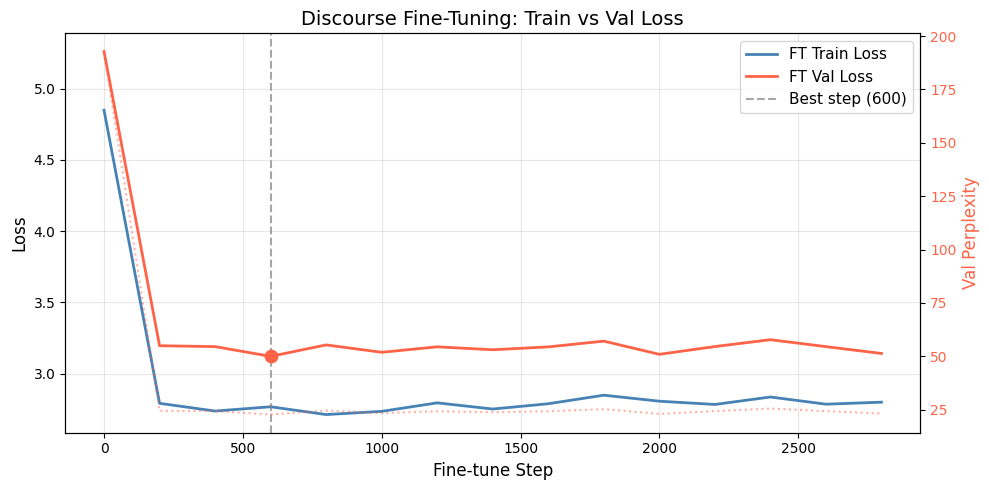

Best val loss : 3.1211 at step 600
Best val PPL  : 22.67
Base PPL      : 25.11
PPL change    : -2.44


In [11]:
def plot_ft_losses(train_losses, val_losses, steps):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, train_losses, label='FT Train Loss',
            color='steelblue', linewidth=2)
    ax.plot(steps, val_losses,   label='FT Val Loss',
            color='tomato',    linewidth=2)

    best_step = steps[val_losses.index(min(val_losses))]
    best_loss = min(val_losses)
    ax.axvline(x=best_step, color='gray', linestyle='--',
               alpha=0.7, label=f'Best step ({best_step})')
    ax.scatter([best_step], [best_loss], color='tomato', zorder=5, s=80)
    ax.set_xlabel('Fine-tune Step', fontsize=12)
    ax.set_ylabel('Loss',           fontsize=12)
    ax.set_title('Discourse Fine-Tuning: Train vs Val Loss', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    val_ppl = [math.exp(l) for l in val_losses]
    ax2.plot(steps, val_ppl, color='tomato', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Val Perplexity', fontsize=12, color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')

    plt.tight_layout()
    plt.savefig('ft_loss_curve.png', dpi=150)
    plt.show()

    print(f'Best val loss : {best_loss:.4f} at step {best_step}')
    print(f'Best val PPL  : {math.exp(best_loss):.2f}')
    if base_ckpt.get('val_loss'):
        base_ppl = math.exp(base_ckpt['val_loss'])
        ft_ppl   = math.exp(best_loss)
        print(f'Base PPL      : {base_ppl:.2f}')
        print(f'PPL change    : {ft_ppl - base_ppl:+.2f}')

plot_ft_losses(ft_train_losses, ft_val_losses, ft_steps)

## Cell 12 — Generate and test

In [12]:
# Reload best checkpoint
ft_ckpt = torch.load(FT_CKPT, map_location=device)
model_ft.load_state_dict(ft_ckpt['model'])
model_ft.eval()
print(f'Loaded: {FT_CKPT}')
print(f'Val loss: {ft_ckpt["val_loss"]:.4f} '
      f'(PPL={math.exp(ft_ckpt["val_loss"]):.2f})')

def generate_story(prompt, model, tokenizer,
                   temperature=0.7, top_k=50,
                   keep_labels=False):
    """
    Generate a 5-sentence story with discourse structure.
    Prepends [SETUP] automatically.
    """
    model.eval()
    cleaned     = clean_story(prompt)
    full_prompt = f'[SETUP] {cleaned}'

    # encode with tokenizer, then remap discourse IDs for model
    raw_ids   = tokenizer.encode(full_prompt)
    remapped  = [DISCOURSE_ID_MAP.get(tid, tid) for tid in raw_ids]
    input_ids = torch.tensor(remapped, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model.generate(
            idx            = input_ids,
            max_new_tokens = 150,
            temperature    = temperature,
            top_k          = top_k
        )

    tokens = output[0].tolist()

    # cut at EOS
    if EOS_TOKEN_ID in tokens:
        tokens = tokens[:tokens.index(EOS_TOKEN_ID)]

    # reverse remap model IDs → tokenizer IDs for decoding
    reverse_map = {v: k for k, v in DISCOURSE_ID_MAP.items()}
    tokens      = [reverse_map.get(tid, tid) for tid in tokens]

    story = tokenizer.decode(tokens, skip_special_tokens=False)

    if not keep_labels:
        for tok in DISCOURSE_TOKENS:
            story = story.replace(tok, '')
        story = re.sub(r'\s+', ' ', story).strip()

    return story


test_prompts = [
    'Emily forgot her umbrella before leaving for work.',
    'Tom wanted to learn how to cook.',
    'Sarah was nervous about her first day at school.',
]

for prompt in test_prompts:
    print(f'\nPrompt: {prompt}')
    print('─' * 60)
    print('With discourse labels:')
    print(generate_story(prompt, model_ft, tokenizer_ft,
                         keep_labels=True))
    print('\nClean output:')
    print(generate_story(prompt, model_ft, tokenizer_ft,
                         keep_labels=False))
    print()

Loaded: out/ckpt_discourse.pt
Val loss: 3.1211 (PPL=22.67)

Prompt: Emily forgot her umbrella before leaving for work.
────────────────────────────────────────────────────────────
With discourse labels:
[SETUP] emily forgot her umbrella before leaving for work. [CONSEQUENCE] she got on her car and drove to work. [RESOLUTION] she was able to walk home without her umbrella at home. [RESOLUTION] she was able to get to work on time. [RESOLUTION] she was able to get home safely.

Clean output:
emily forgot her umbrella before leaving for work. she didn't have any umbrella so she thought it was not too late. she decided to check the weather out. she had to walk to the store to buy a new one.


Prompt: Tom wanted to learn how to cook.
────────────────────────────────────────────────────────────
With discourse labels:
[SETUP] tom wanted to learn how to cook. [CONSEQUENCE] he worked hard on his recipes. [CONSEQUENCE] the day of the cookout came. [RESOLUTION] tom tried out. [RESOLUTION] he made 

## Cell 13 — Resume fine-tuning from any checkpoint

To continue fine-tuning, update Cell 2 and re-run Cells 2 → 10:
```python
BASE_CKPT = 'out/ckpt_discourse.pt'   # your previous FT checkpoint
FT_CKPT   = 'out/ckpt_discourse_v2.pt'
FT_LR     = 5e-6    # even lower LR
FT_ITERS  = 1000
```

**Cell 14** Testing on ROC Test

In [36]:
# ── Cell 14: Evaluate fine-tuned model on roc_test ─────────────────────────


from datasets import load_dataset
from sklearn.model_selection import train_test_split
from contextlib import nullcontext
import re, math, torch
from transformers import GPT2Tokenizer

# ── Reproduce the same train/val/test split as Cell 6 ─────────────────
print('Loading ROCStories for evaluation...')
ROC_stories = load_dataset('mintujupally/ROCStories')
roc_test = ROC_stories['test'][:]['text']


# ── Prepare test stories: label with discourse tags ───────────────────
def prepare_evaluation_stories(stories, split_name='test'):
    """Return a list of discourse-labelled strings, one per valid story."""
    labelled = []
    skipped = 0
    for story in stories:
        if not is_valid_story(story):
            skipped += 1
            continue
        cleaned = normalize_sentences(clean_story(story))
        disc = label_discourse(cleaned)
        if disc is None:
            skipped += 1
            continue
        labelled.append(disc)
    print(f'[{split_name}] {len(labelled):,} stories prepared ({skipped} skipped)')
    if labelled:
        print(f'  Sample: {labelled[0][:120]}...')
    return labelled

test_stories = prepare_evaluation_stories(roc_test, 'roc_test')


Loading ROCStories for evaluation...


Repo card metadata block was not found. Setting CardData to empty.


[roc_test] 19,479 stories prepared (154 skipped)
  Sample: [SETUP] david had achieved his lifelong goal. [CONSEQUENCE] he had just become a pilot! [CONSEQUENCE] he had learned how...


In [37]:
# ── Load fine-tuned model ─────────────────────────────────────────────
print(f'Loading fine-tuned model from {FT_CKPT}...')
ft_ckpt = torch.load(FT_CKPT, map_location=device)

# Rebuild tokenizer exactly as in Cell 4
tokenizer_eval = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer_eval.pad_token = tokenizer_eval.eos_token
tokenizer_eval.add_special_tokens({'additional_special_tokens': list(DISCOURSE_TOKENS)})

# Discourse ID map (prefer checkpoint value, fall back to Cell 4 mapping)
DISCOURSE_ID_MAP = ft_ckpt.get('discourse_id_map', {
    tokenizer_eval.convert_tokens_to_ids('[SETUP]'):       tokenizer_eval.convert_tokens_to_ids('[SETUP]'),
    tokenizer_eval.convert_tokens_to_ids('[CONSEQUENCE]'): tokenizer_eval.convert_tokens_to_ids('[CONSEQUENCE]'),
    tokenizer_eval.convert_tokens_to_ids('[RESOLUTION]'):  tokenizer_eval.convert_tokens_to_ids('[RESOLUTION]'),
})

# Build model from checkpoint
gptconf = GPTConfig(**ft_ckpt['model_args'])
model_eval = GPT(gptconf)
state_dict = ft_ckpt['model']
unwanted_prefix = '_orig_mod.'
for k in list(state_dict.keys()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model_eval.load_state_dict(state_dict)
model_eval.eval()
model_eval.to(device)
print(f'Model loaded — vocab: {model_eval.config.vocab_size}, '
      f'params: {sum(p.numel() for p in model_eval.parameters())/1e6:.2f}M')

# ── Mixed-precision context (matches training dtype) ──────────────────
device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype_str    = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype      = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype_str]
eval_ctx     = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# ── Evaluation loop ────────────────────────────────────────────────────
total_nll     = 0.0
total_tokens  = 0
used_stories  = 0
skipped_short = 0
block_size    = model_eval.config.block_size

print(f'Evaluating on {len(test_stories):,} test stories...')
with torch.no_grad():
    with eval_ctx:
        for idx, story in enumerate(test_stories):
            token_ids = tokenizer_eval.encode(story)
            # Remap discourse token IDs to the model's extended positions
            token_ids = [DISCOURSE_ID_MAP.get(t, t) for t in token_ids]

            if len(token_ids) < 2:
                skipped_short += 1
                continue

            pos = 0
            n_pred = len(token_ids) - 1   # number of next-token predictions

            while pos < n_pred:
                inp = token_ids[pos : pos + block_size]
                tgt = token_ids[pos + 1 : pos + 1 + block_size]

                if not tgt:
                    break
                # Ensure inp and tgt are the same length
                min_len = min(len(inp), len(tgt))
                inp, tgt = inp[:min_len], tgt[:min_len]

                x = torch.tensor(inp, dtype=torch.long, device=device).unsqueeze(0)
                y = torch.tensor(tgt, dtype=torch.long, device=device).unsqueeze(0)

                _, loss = model_eval(x, y)

                total_nll    += loss.item() * min_len
                total_tokens += min_len
                pos          += min_len

            used_stories += 1

            if (idx + 1) % 500 == 0:
                print(f'  {idx + 1}/{len(test_stories)} stories processed...')

# ── Results ───────────────────────────────────────────────────────────
if total_tokens == 0:
    raise ValueError('No valid tokens evaluated. Check roc_test preparation.')

avg_loss = total_nll / total_tokens
ppl      = math.exp(avg_loss)

print('' + '=' * 52)
print('EVALUATION RESULTS  (roc_test)')
print('=' * 52)
print(f'Checkpoint      : {FT_CKPT}')
print(f'Stories used    : {used_stories:,}')
print(f'Stories skipped : {skipped_short}  (< 2 tokens)')
print(f'Total tokens    : {total_tokens:,}')
print(f'Avg NLL loss    : {avg_loss:.4f}')
print(f'Perplexity      : {ppl:.2f}')
print('=' * 52)

# Optional: compare against base checkpoint val loss recorded during fine-tuning
if ft_ckpt.get('base_val_loss'):
    base_ppl = math.exp(ft_ckpt['base_val_loss'])
    delta    = base_ppl - ppl
    print(f'Comparison vs base checkpoint:')
    print(f'  Base PPL : {base_ppl:.2f}')
    print(f'  FT PPL   : {ppl:.2f}')
    print(f'  Delta    : {delta:+.2f}  ({delta / base_ppl * 100:+.1f}%)')


Loading fine-tuned model from out/ckpt_discourse.pt...
number of parameters: 29.94M
Model loaded — vocab: 50307, params: 29.99M
Evaluating on 19,479 test stories...
  500/19479 stories processed...
  1000/19479 stories processed...
  1500/19479 stories processed...
  2000/19479 stories processed...
  2500/19479 stories processed...
  3000/19479 stories processed...
  3500/19479 stories processed...
  4000/19479 stories processed...
  4500/19479 stories processed...
  5000/19479 stories processed...
  5500/19479 stories processed...
  6000/19479 stories processed...
  6500/19479 stories processed...
  7000/19479 stories processed...
  7500/19479 stories processed...
  8000/19479 stories processed...
  8500/19479 stories processed...
  9000/19479 stories processed...
  9500/19479 stories processed...
  10000/19479 stories processed...
  10500/19479 stories processed...
  11000/19479 stories processed...
  11500/19479 stories processed...
  12000/19479 stories processed...
  12500/19479 s